In [1]:
import anndata
import numpy as np
import gc
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2-wmeta-ccf.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3739961 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

In [3]:
# Subseeting data to microglia cells
mg_adata = adata[adata.obs['subclass'] == '334 Microglia NN']
mg_adata

View of AnnData object with n_obs × n_vars = 48745 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

In [4]:
# Saving the microglia data to file
# sc.write('/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-microglia-imputed-log2-wmeta-ccf.h5ad', mg_adata)

### Plotting microglia in a Z section

In [4]:
def plot_section_with_legend(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")

    elif legends is not None and cc is not None:
        # Ensure pandas Series, drop NaNs
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()

        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]

        unique_labels = legends.unique()

        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]  # assume consistent color per label
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc = "right", bbox_to_anchor=(1.4, 0.5))

    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)

    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [5]:
# Selecting a z slice
mg_adata_z = mg_adata[mg_adata.obs['brain_section_label'] == 'C57BL6J-638850.40']
mg_adata_z

View of AnnData object with n_obs × n_vars = 1450 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

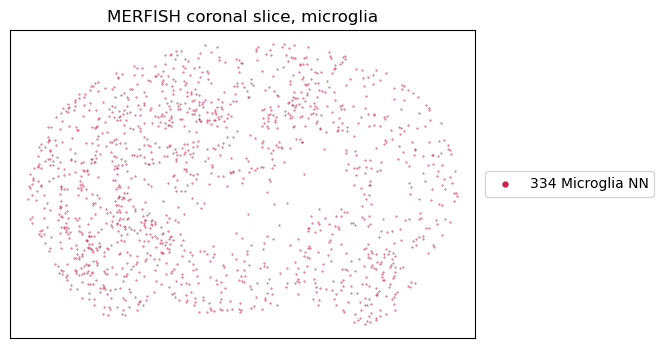

In [6]:
fig, ax = plot_section_with_legend(mg_adata_z.obs['x_reconstructed'],
                                   mg_adata_z.obs['y_reconstructed'],
                                   cc = mg_adata_z.obs['subclass_color'],
                                   legends=mg_adata_z.obs['subclass'],
                                   fig_height=4,
                                   fig_width=6)
res = ax.set_title("MERFISH coronal slice, microglia")
plt.show()

### Plotting modules in microglia

In [7]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Microglia-raw-meta-wgcna-modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())

All module colors (names):  ['turquoise' 'grey' 'brown' 'blue' 'yellow']


In [15]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.scale(mg_adata_z)  # Scale the data

# Get unique modules and their gene lists
module_gene_dict = modules_df.groupby("module")["gene_name"].apply(list).to_dict()

# Store eigengenes in a DataFrame
eigengenes = pd.DataFrame(index=mg_adata_z.obs_names)

for module, genes in module_gene_dict.items():
    
    if module == "grey":  # Skip the grey module (unassigned genes)
        continue
    
    # Filter genes present in adata
    genes_in_adata = [g for g in genes if g in mg_adata_z.var_names]
    if len(genes_in_adata) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    print(f"Processing module: {module} with genes: {len(genes_in_adata)}")
    X = mg_adata_z[:, genes_in_adata].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes[module] = eigengene

eigengenes.head()

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Processing module: blue with genes: 161
Processing module: brown with genes: 27
Processing module: turquoise with genes: 297


,blue,brown,turquoise
cell_label,,,
1019171907102560390-1,7.053928,-0.100078,-20.916427
1019171907103340477,2.685653,0.971631,-5.116435
1019171907100960300-1,-1.814761,-1.225002,4.089739
1019171907103140375,-4.056866,-1.196629,7.492964
1019171907102010419-1,-0.219823,0.787154,-0.334012


In [24]:
def plot_ME(xx, yy, eigengenes_df, select_module, vmin=None, vmax=None, cmap=None, fig_width=8, fig_height=8, cbar_label=None, title=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    scatter_plot = None  # To hold the scatter plot object
    
    # PCA component coloring
    val = eigengenes_df[select_module]
    cmap = cmap or 'viridis'
    vmin = vmin or np.percentile(val, 1)
    vmax = vmax or np.percentile(val, 99)
    scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar_label = cbar_label or f'ME expression'
    
    # Add color bar if needed
    if scatter_plot is not None:
        cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.6, aspect=10)
        if cbar_label:
            cbar.set_label(cbar_label, rotation=270, labelpad=15)
    
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')

    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Module eigengene for {select_module}")
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'Activation of "Classical Inflammation" module'}>)

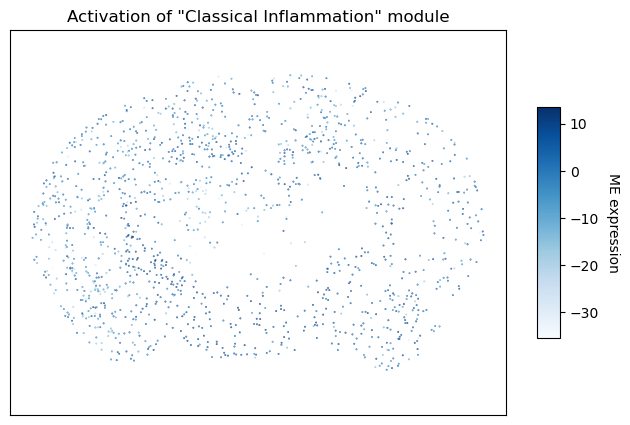

In [30]:
plot_ME(
    mg_adata_z.obs['x_reconstructed'],
    mg_adata_z.obs['y_reconstructed'],
    eigengenes_df=eigengenes,
    select_module="turquoise",
    fig_height=5,
    cmap = "Blues",
    title= "Activation of \"Classical Inflammation\" module")

### Information retained in smaller modules

In [32]:
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# Parameters
module_name = "turquoise"
top_n = 10

# Use the existing full eigengene
eigengene_all = eigengenes[module_name]

# Get ordered list of genes for the module
ordered_genes = modules_df.loc[modules_df["module"] == module_name, "gene_name"].tolist()
genes_in_adata = [g for g in ordered_genes if g in mg_adata_z.var_names]

if len(genes_in_adata) < top_n:
    raise ValueError(f"Not enough valid genes for top {top_n} in module {module_name}.")

# Get expression matrix for top N genes
top_genes = genes_in_adata[:top_n]
X_top = mg_adata_z[:, top_genes].X
if not isinstance(X_top, np.ndarray):
    X_top = X_top.toarray()

# Compute top-N eigengene
pca_top = PCA(n_components=1)
eigengene_top = pca_top.fit_transform(X_top).flatten()

# Correlation
corr, _ = pearsonr(eigengene_all, eigengene_top)

print(f"Correlation between precomputed full and top {top_n} eigengene for module {module_name}: {corr:.3f}")

Correlation between precomputed full and top 10 eigengene for module turquoise: 0.676


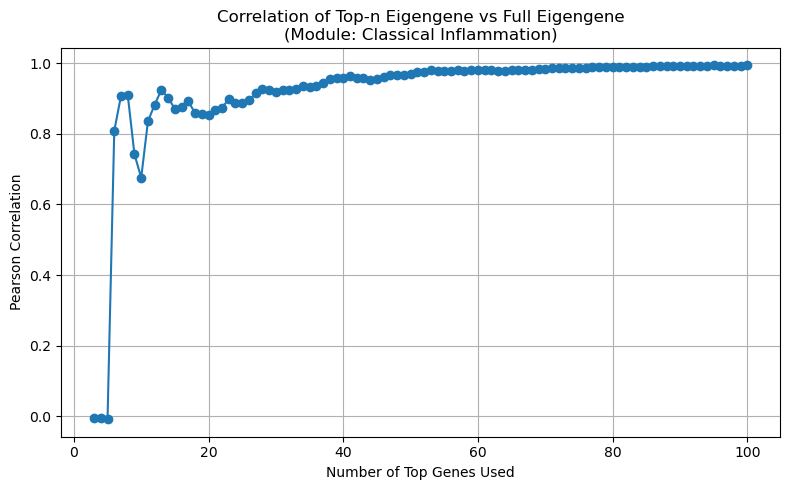

In [35]:
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# Parameters
module_name = "turquoise"
min_genes = 3
max_genes = 100

# Precomputed full-module eigengene
eigengene_full = eigengenes[module_name]

# Get ordered list of genes in the module
ordered_genes = modules_df.loc[modules_df["module"] == module_name, "gene_name"].tolist()
genes_in_adata = [g for g in ordered_genes if g in mg_adata_z.var_names]

# Initialize results
top_ns = []
correlations = []

# Loop through top_n values
for top_n in range(min_genes, min(max_genes + 1, len(genes_in_adata) + 1)):
    top_genes = genes_in_adata[:top_n]
    X_top = mg_adata_z[:, top_genes].X
    if not isinstance(X_top, np.ndarray):
        X_top = X_top.toarray()

    pca_top = PCA(n_components=1)
    eigengene_top = pca_top.fit_transform(X_top).flatten()

    corr, _ = pearsonr(eigengene_full, eigengene_top)
    top_ns.append(top_n)
    correlations.append(corr)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(top_ns, correlations, marker='o')
plt.title(f"Correlation of Top-n Eigengene vs Full Eigengene\n(Module: Classical Inflammation)")
plt.xlabel("Number of Top Genes Used")
plt.ylabel("Pearson Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/top_n_correlation_{module_name}.svg", dpi=300)
plt.show()

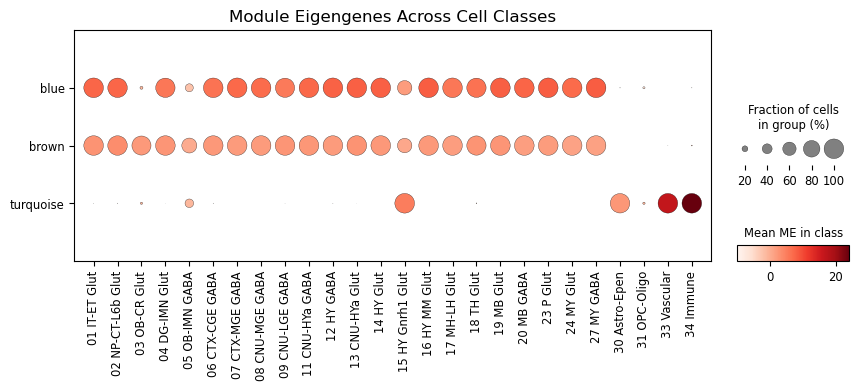

In [7]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes)
adata_vis.obs["class"] = adata.obs["class"]  # Add cell type labels

# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=adata_vis.var_names,  # Use eigengenes as variables
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 3),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    # save = "Isocortex_CNA.svg"
)

In [23]:
def map_symbols_to_ids_list(gene_symbols, adata_var):
    """
    Map a list of gene symbols to a list of gene identifiers using adata.var.

    Parameters:
        gene_symbols (list): List of gene symbols to map.
        adata_var (pd.DataFrame): adata.var DataFrame with 'gene_symbol' column.

    Returns:
        list: List of gene identifiers (index in adata.var), or None if not found.
    """
    mapped_ids = []
    for symbol in gene_symbols:
        matches = adata_var.index[adata_var['gene_symbol'] == symbol].tolist()
        mapped_ids.append(matches[0] if matches else None)
    return mapped_ids

# Example usage:
gene_symbols = ['Tmem119', 'P2ry12', 'Cx3cr1']
mapped_ids = map_symbols_to_ids_list(gene_symbols, adata.var)
print(mapped_ids)

['ENSMUSG00000054675', 'ENSMUSG00000036353', 'ENSMUSG00000052336']


In [ ]:
# Map gene symbols to gene identifiers using adata.var
# adata.var should have 'gene_symbol' as a column and index as gene identifiers

def map_symbols_to_ids(gene_symbols, adata_var):
    """
    Map a list of gene symbols to gene identifiers using adata.var.

    Parameters:
        gene_symbols (list): List of gene symbols to map.
        adata_var (pd.DataFrame): adata.var DataFrame with 'gene_symbol' column.

    Returns:
        dict: Mapping from gene symbol to gene identifier (index in adata.var).
    """
    # Build a reverse mapping from symbol to index
    symbol_to_id = adata_var.reset_index().set_index('gene_symbol').index
    mapping = {}
    for symbol in gene_symbols:
        matches = adata_var.index[adata_var['gene_symbol'] == symbol].tolist()
        if matches:
            mapping[symbol] = matches[0]  # Take the first match if multiple
        else:
            mapping[symbol] = None  # Not found
    return mapping

# Example usage:
gene_symbols = ['Tmem119', 'P2ry12', 'Cx3cr1']
symbol_to_id_map = map_symbols_to_ids(gene_symbols, adata.var)
print(symbol_to_id_map)

{'Tmem119': 'ENSMUSG00000054675', 'P2ry12': 'ENSMUSG00000036353', 'Cx3cr1': 'ENSMUSG00000052336'}


{'Aif1': 'ENSMUSG00000024397', 'Itgam': 'ENSMUSG00000030786', 'P2ry12': 'ENSMUSG00000036353', 'Olig1': 'ENSMUSG00000046160', 'Gfap': 'ENSMUSG00000020932'}


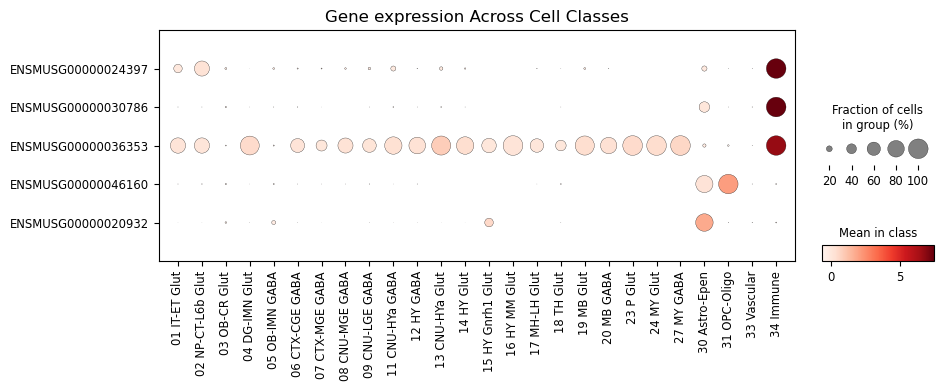

In [26]:
genes_to_plot = ["Aif1", "Itgam", "P2ry12", "Olig1", "Gfap"]
print(map_symbols_to_ids(genes_to_plot, adata.var))

# Matrixplot
sc.pl.dotplot(
    adata,
    var_names=map_symbols_to_ids_list(genes_to_plot, adata.var),  # Use eigengenes as variables
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 3),  # Adjust size as needed
    title="Gene expression Across Cell Classes",
    colorbar_title="Mean in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    # save = "Isocortex_CNA.svg"
)

In [30]:
# Reading the codebook file
codebook_df = pd.read_csv('/data/MERFISH/codebook.csv', index_col=0)
print(codebook_df.head())

        bit01  bit02  bit03  bit04  bit05  bit06  bit07  bit08  bit09  bit10  \
Adgre1      0      0      0      0      1      1      1      0      0      0   
Adrb2       0      0      0      0      1      0      1      0      0      0   
Angpt1      1      0      0      0      1      0      1      0      0      0   
Angpt2      0      0      1      0      1      0      1      1      0      0   
Axl         0      0      0      0      1      1      0      1      0      0   

        bit11  bit12  bit13  bit14  bit15  bit16  
Adgre1      0      0      0      0      1      0  
Adrb2       0      1      0      0      0      1  
Angpt1      0      0      1      0      0      0  
Angpt2      0      0      0      0      0      0  
Axl         0      1      0      0      0      0  


In [38]:
adata.var_names = adata.var["gene_symbol"].astype(str)

In [41]:
adata.var_names_make_unique()

In [43]:
genes_in_both = [gene for gene in codebook_df.index if gene in adata.var_names]
print(genes_in_both)

['Adgre1', 'Angpt1', 'Angpt2', 'Axl', 'Btg2', 'Cd109', 'Cd14', 'Cd44', 'Cd72', 'Ctsb', 'Cx3cr1', 'Cybb', 'Dcx', 'Ddit4', 'Dll1', 'Dpysl2', 'Egr1', 'Fcrls', 'Fos', 'Ifit1', 'Ifit2', 'Ifit3', 'Igf1', 'Itgam', 'Jag1', 'Jun', 'Junb', 'Jund', 'Lpl', 'Lrba', 'Ly6e', 'Mog', 'Notch1', 'Notch2', 'Notch3', 'Notch4', 'Oasl2', 'Olig1', 'Pgk1', 'Ptprc', 'Rbfox3', 'Serinc3', 'Serpina3n', 'Serpine2', 'Serping1', 'Slc7a8', 'Smad7', 'Sox4', 'Sparc', 'Stat1', 'Stat3', 'Tek', 'Tgfbr2', 'Tlr4', 'Tmem119', 'Tsc22d3', 'Ucp2', 'Vcam1', 'Vim', 'Zfp36', 'Aif1', 'Apoe', 'Arg1', 'Birc5', 'C1qa', 'Ccl2', 'Ccl3', 'Ccl4', 'Cd63', 'Cd68', 'Cd74', 'Cst3', 'Ctss', 'Epha10', 'Gfap', 'H2-Ab1', 'H2-D1', 'H2-T23', 'Il1b', 'Irf1', 'Klf2', 'P2ry12', 'Rtp4', 'Spp1', 'Trem2']


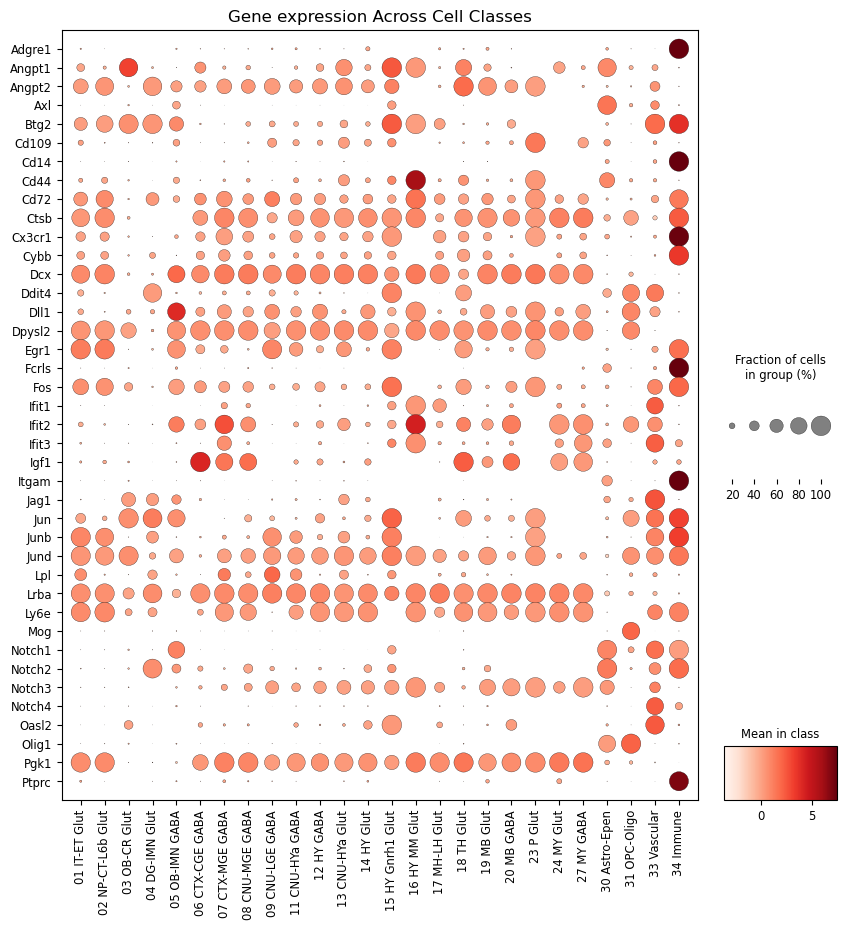

In [48]:
# Matrixplot
sc.pl.dotplot(
    adata,
    var_names=genes_in_both[:40],  # Use eigengenes as variables
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 10),  # Adjust size as needed
    title="Gene expression Across Cell Classes",
    colorbar_title="Mean in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    # save = "Isocortex_CNA.svg"
)

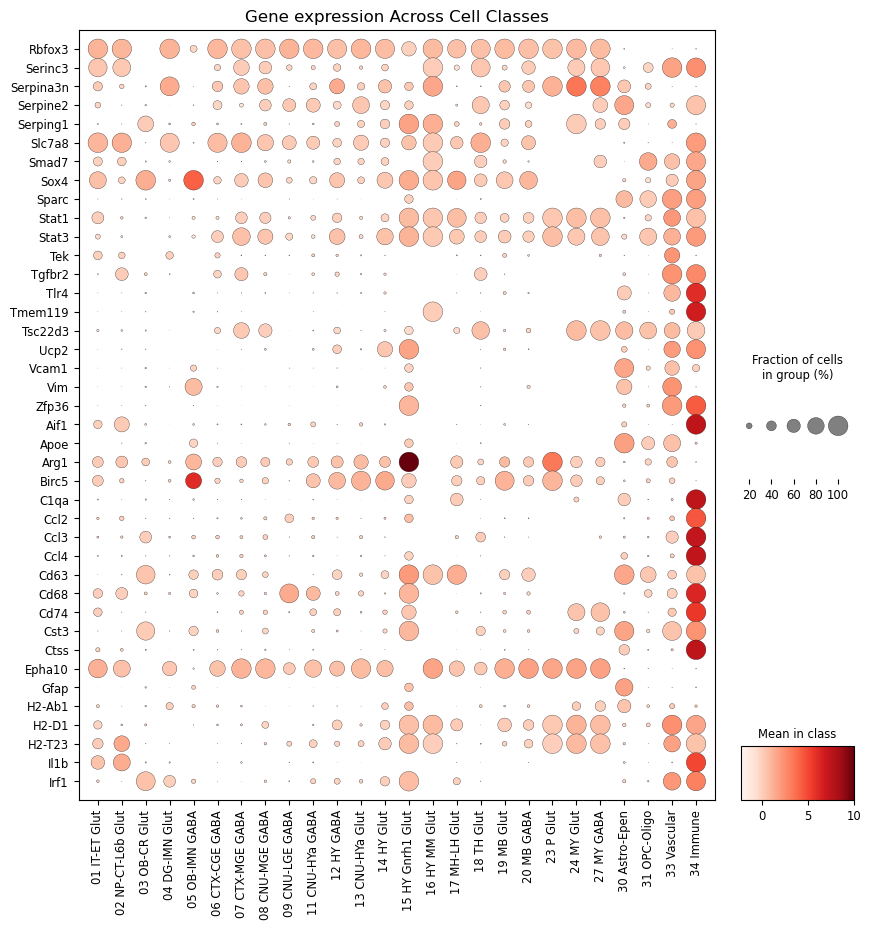

In [51]:
# Matrixplot
sc.pl.dotplot(
    adata,
    var_names=genes_in_both[40:80],  # Use eigengenes as variables
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 10),  # Adjust size as needed
    title="Gene expression Across Cell Classes",
    colorbar_title="Mean in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    vmax = 10
    # save = "Isocortex_CNA.svg"
)

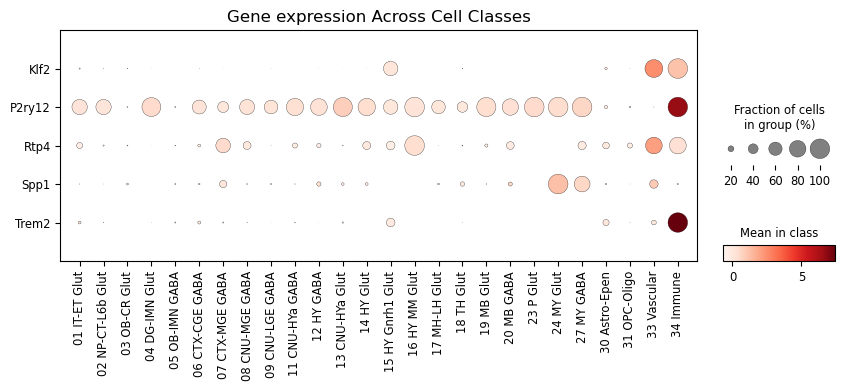

In [53]:
# Matrixplot
sc.pl.dotplot(
    adata,
    var_names=genes_in_both[80:],  # Use eigengenes as variables
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 3),  # Adjust size as needed
    title="Gene expression Across Cell Classes",
    colorbar_title="Mean in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    # vmax = 10
    # save = "Isocortex_CNA.svg"
)

In [39]:
# genes_to_plot = codebook_df.index
# # print(map_symbols_to_ids(genes_to_plot, adata.var))
# list(filter(None, map_symbols_to_ids_list(genes_to_plot, adata.var)))

## ME in all cells

In [17]:
def plot_pca(xx, yy, cc=None, val=None, adata=None, pc_component=None, 
                 fig_width=8, fig_height=8, cmap=None, cbar_label=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    scatter_plot = None  # To hold the scatter plot object
    
    # PCA component coloring
    if pc_component is not None:
        if adata is None:
            raise ValueError("adata must be provided when using pc_component.")
        val = adata.obsm['X_pca'][:, pc_component]
        cmap = cmap or 'viridis'
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or f'PC{pc_component + 1}'  # Auto-label for PCA
        
    # Regular colormap coloring
    elif cmap is not None:
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or 'Value'  # Default label
        
    # Categorical color list
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    # Default to black
    else:
        ax.scatter(xx, yy, s=0.5, color='k', marker='.')
    
    # Add color bar if needed
    if scatter_plot is not None:
        cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.6, aspect=10)
        if cbar_label:
            cbar.set_label(cbar_label, rotation=270, labelpad=15)
    
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    plt.title(f'Module Eigengene for module: {select_module}')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [ ]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = adata.var_names.intersection(select_genes)
adata_subset = adata[:,common_genes].copy()
adata_subset.X = adata_subset.X.astype("float32")
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_section = adata_subset[adata_subset.obs['brain_section_label'] == 'C57BL6J-638850.38']
plot_pca(adata_section.obs['x_reconstructed'], adata_section.obs['y_reconstructed'], adata=adata_section, pc_component=0, cmap='viridis')

/tmp/ipykernel_2416935/1140654524.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_pca_df = pca_df.groupby('class').mean()


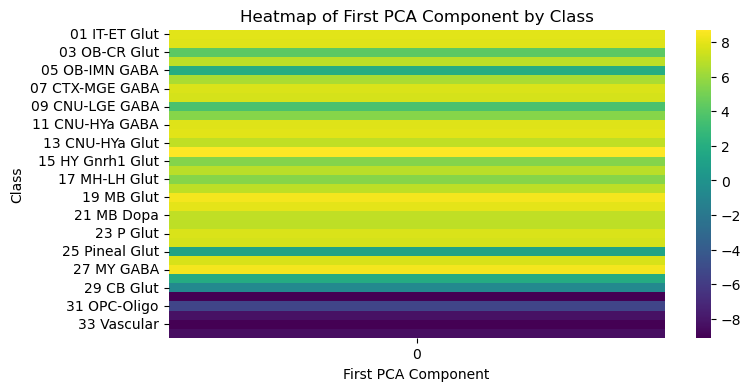

Top 10 subclasses with the highest mean value for the first PCA component:
class
14 HY Glut           8.722157
27 MY GABA           8.434464
19 MB Glut           8.390781
20 MB GABA           7.964190
12 HY GABA           7.935624
01 IT-ET Glut        7.931221
02 NP-CT-L6b Glut    7.886264
11 CNU-HYa GABA      7.836250
23 P Glut            7.701991
07 CTX-MGE GABA      7.681602
Name: 0, dtype: float32


In [20]:
# Create a DataFrame for the PCA components and class
pca_df = pd.DataFrame(adata_subset.obsm['X_pca'], index=adata_subset.obs.index)
pca_df['class'] = adata_subset.obs['class']

# Compute the mean PCA components for each subclass
mean_pca_df = pca_df.groupby('class').mean()

# Show only the first PCA component
plt.figure(figsize=(8, 4))
sns.heatmap(mean_pca_df[[0]], cmap='viridis', annot=False)
plt.title('Heatmap of First PCA Component by Class')
plt.xlabel('First PCA Component')
plt.ylabel('Class')
plt.show()

# Get the top 10 subclasses with the highest mean value for the first PCA component
top_10_active_subclasses = mean_pca_df[0].nlargest(10)
print("Top 10 subclasses with the highest mean value for the first PCA component:")
print(top_10_active_subclasses)

In [21]:
'''
Module specificity with Tau score
'''
# Shift the eigengene values to ensure non-negativity
tau_df = adata_subset.obs[["class"]].copy()
tau_df[select_module] = adata_subset.obsm['X_pca'][:,0]
tau_df[select_module] = tau_df[select_module] - tau_df[select_module].min() + 1e-6

# Compute average eigengene per cell class
avg_expression = tau_df.groupby('class', observed = False)[select_module].mean()

# Normalize by the maximum average expression
max_expr = avg_expression.max()
normalized_expr = avg_expression / max_expr

# Compute tau score
tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
print(f"Tau specificity score for the module: {tau:.3f}")

Tau specificity score for the module: 0.201
